# Question 1 

In [1]:
import numpy as np
from q1 import simulate_lognormal_sum, wasserstein_1d, reject_abc


In [ ]:
seed_value = 42
main_rng = np.random.default_rng(seed_value)
    
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200  
    
print("Generating strictly defined observational data...")
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=main_rng)

##### epsilon and the prior affect the result ###
    
epsilon_val = 0.5 
    
prior_configs = [
        {"s": 1.0, "t": 1.0, "name": "Well-calibrated"},
        {"s": 10.0, "t": 10.0, "name": "Highly diffuse (Efficiency drop)"},
        {"s": 0.01, "t": 0.01, "name": "Highly concentrated (Prior bias risk)"}
    ]
    
print(f"\n--- Rejection-ABC Empirical Results (Target: mu={mu_true}, sigma={sigma_true}) ---")
for config in prior_configs:
    print(f"\nEvaluating '{config['name']}' prior specification (s={config['s']}, t={config['t']}):")
        
        # Pass the isolated generator down the execution pipeline
    samples, acc_rate = reject_abc(
        Y_obs, L_true, config['s'], config['t'], epsilon_val, num_samples=50, rng=main_rng
        )
        
    print(f"  -> Acceptance Rate : {acc_rate:.4%}")
        
    if len(samples) > 0:
        mu_est = np.mean(samples[:, 0])
        sigma_est = np.mean(samples[:, 1])
        print(f"  -> Estimated mu    : {mu_est:.4f}")
        print(f"  -> Estimated sigma : {sigma_est:.4f}")
    else:
        print("  -> Estimated mu    : N/A (0 samples accepted)")
        print("  -> Estimated sigma : N/A (0 samples accepted)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from q1 import simulate_lognormal_sum, wasserstein_1d, reject_abc

# ─────────────────────────────────────────────
#  GLOBAL SEED & TRUE PARAMETERS
# ─────────────────────────────────────────────


    
SEED      = 42
L_TRUE    = 10
MU_TRUE   = 0.0
SIGMA_TRUE = 0.3
N_OBS     = 200
N_SAMPLES = 200   # accepted samples per run (increase for smoother plots)

main_rng = np.random.default_rng(SEED)
Y_obs = simulate_lognormal_sum(N_OBS, L_TRUE, MU_TRUE, SIGMA_TRUE, rng=main_rng)

# ─────────────────────────────────────────────
#  STYLE
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f14",
    "axes.facecolor":   "#16161f",
    "axes.edgecolor":   "#3a3a52",
    "axes.labelcolor":  "#c8c8e0",
    "xtick.color":      "#7a7a9a",
    "ytick.color":      "#7a7a9a",
    "text.color":       "#c8c8e0",
    "grid.color":       "#2a2a3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "axes.titlesize":   10,
    "axes.labelsize":   9,
})

ACCENT   = ["#7eb8f7", "#f7a07e", "#7ef7c0"]   # blue / orange / green
TRUE_CLR = "#ff4f6e"
PRIOR_CLR = "#a07ef7"


# ─────────────────────────────────────────────
#  HELPER : confidence ellipse (1-sigma)
# ─────────────────────────────────────────────
def plot_ellipse(ax, samples, color, n_std=2.0):
    if len(samples) < 3:
        return
    cov = np.cov(samples[:, 0], samples[:, 1])
    mean = samples.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mean, width=w, height=h, angle=angle,
                  edgecolor=color, facecolor="none", lw=1.5, linestyle="--", alpha=0.7)
    ax.add_patch(ell)


# ═══════════════════════════════════════════════════════════════
#  FIGURE 1 — Impact of prior (s, t)   [epsilon fixed]
# ═══════════════════════════════════════════════════════════════
EPSILON_FIXED = 0.5
PRIOR_CONFIGS = [
    {"s": 1.0,  "t": 1.0,  "name": "Well-calibrated\n(s=t=1)"},
    {"s": 10.0, "t": 10.0, "name": "Highly diffuse\n(s=t=10)"},
    {"s": 0.01, "t": 0.01, "name": "Highly concentrated\n(s=t=0.01)"},
]

fig1, axes1 = plt.subplots(3, 3, figsize=(14, 11))
fig1.suptitle(
    f"Reject-ABC — Impact of Prior   [ε = {EPSILON_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5", y=0.98
)

for col, cfg in enumerate(PRIOR_CONFIGS):
    rng = np.random.default_rng(SEED + col)          # isolated seed per config
    samples, acc_rate = reject_abc(
        Y_obs, L_TRUE, cfg["s"], cfg["t"],
        EPSILON_FIXED, num_samples=N_SAMPLES,
        max_attempts=200_000, rng=rng
    )

    color = ACCENT[col]
    ax_sc  = axes1[0, col]
    ax_mu  = axes1[1, col]
    ax_sig = axes1[2, col]

    # ── column title ──
    ax_sc.set_title(
        f"{cfg['name']}\nAcc. rate = {acc_rate:.3%}",
        color=color, pad=8
    )

    # ── ROW 0 : scatter (mu, sigma) ──
    if len(samples) > 0:
        ax_sc.scatter(samples[:, 0], samples[:, 1],
                      alpha=0.35, s=12, color=color, rasterized=True)
        plot_ellipse(ax_sc, samples, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.4, linestyle="-",  label=f"μ*={MU_TRUE}")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.4, linestyle="--", label=f"σ*={SIGMA_TRUE}")
    ax_sc.set_xlabel("μ")
    ax_sc.set_ylabel("σ")
    ax_sc.legend(fontsize=7, loc="upper right")
    ax_sc.grid(True)

    # ── ROW 1 : histogram of mu ──
    if len(samples) > 0:
        ax_mu.hist(samples[:, 0], bins=25, density=True,
                   color=color, alpha=0.7, edgecolor="#0f0f14")
    # overlay prior
    x_range = np.linspace(-4 * cfg["s"], 4 * cfg["s"], 300)
    prior_pdf = (1 / (cfg["s"] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_range / cfg["s"]) ** 2)
    ax_mu.plot(x_range, prior_pdf, color=PRIOR_CLR, lw=1.5, alpha=0.8, label="Prior π(μ)")
    ax_mu.axvline(MU_TRUE, color=TRUE_CLR, lw=1.5, label=f"μ*={MU_TRUE}")
    if len(samples) > 0:
        ax_mu.axvline(samples[:, 0].mean(), color=color, lw=1.5,
                      linestyle="--", label=f"μ̂={samples[:,0].mean():.3f}")
    ax_mu.set_xlabel("μ")
    ax_mu.set_ylabel("Density")
    ax_mu.legend(fontsize=7)
    ax_mu.grid(True)

    # ── ROW 2 : histogram of sigma ──
    if len(samples) > 0:
        ax_sig.hist(samples[:, 1], bins=25, density=True,
                    color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_sig.axvline(SIGMA_TRUE, color=TRUE_CLR, lw=1.5, label=f"σ*={SIGMA_TRUE}")
    if len(samples) > 0:
        ax_sig.axvline(samples[:, 1].mean(), color=color, lw=1.5,
                       linestyle="--", label=f"σ̂={samples[:,1].mean():.3f}")
    ax_sig.set_xlabel("σ")
    ax_sig.set_ylabel("Density")
    ax_sig.legend(fontsize=7)
    ax_sig.grid(True)

fig1.tight_layout(rect=[0, 0, 1, 0.97])
fig1.savefig("fig1_prior_impact.png", dpi=150, bbox_inches="tight", facecolor=fig1.get_facecolor())
print("Saved: fig1_prior_impact.png")


# ═══════════════════════════════════════════════════════════════
#  FIGURE 2 — Impact of epsilon   [prior fixed: s=t=1]
# ═══════════════════════════════════════════════════════════════
S_FIXED = 1.0
T_FIXED = 1.0
EPSILONS = [0.1, 0.3, 0.5, 1.0, 2.0]

results_eps = []
for eps in EPSILONS:
    rng = np.random.default_rng(SEED + 100)
    samp, rate = reject_abc(
        Y_obs, L_TRUE, S_FIXED, T_FIXED,
        eps, num_samples=N_SAMPLES,
        max_attempts=500_000, rng=rng
    )
    results_eps.append({
        "eps":      eps,
        "samples":  samp,
        "rate":     rate,
        "mu_hat":   samp[:, 0].mean() if len(samp) > 0 else np.nan,
        "sigma_hat": samp[:, 1].mean() if len(samp) > 0 else np.nan,
    })
    print(f"ε={eps:.2f}  acc={rate:.4%}  μ̂={results_eps[-1]['mu_hat']:.4f}  σ̂={results_eps[-1]['sigma_hat']:.4f}")

n_eps = len(EPSILONS)
cmap  = plt.cm.plasma
eps_colors = [cmap(i / (n_eps - 1)) for i in range(n_eps)]

fig2 = plt.figure(figsize=(16, 9))
fig2.suptitle(
    f"Reject-ABC — Impact of ε   [s=t={S_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5"
)

gs = fig2.add_gridspec(2, n_eps + 1, hspace=0.38, wspace=0.35,
                        width_ratios=[1.4] + [1] * n_eps)

# ── left column: 3 summary curves (acceptance rate, mu_hat, sigma_hat) ──
ax_rate  = fig2.add_subplot(gs[0, 0])
ax_est   = fig2.add_subplot(gs[1, 0])

eps_vals  = [r["eps"]      for r in results_eps]
rates     = [r["rate"]     for r in results_eps]
mu_hats   = [r["mu_hat"]   for r in results_eps]
sig_hats  = [r["sigma_hat"] for r in results_eps]

# acceptance rate
ax_rate.plot(eps_vals, rates, "o-", color="#7eb8f7", lw=2, ms=7)
for i, (e, r) in enumerate(zip(eps_vals, rates)):
    ax_rate.annotate(f"{r:.2%}", (e, r), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7, color=eps_colors[i])
ax_rate.set_title("Acceptance rate vs ε")
ax_rate.set_xlabel("ε")
ax_rate.set_ylabel("Acceptance rate")
ax_rate.grid(True)

# mu_hat and sigma_hat
ax_est.plot(eps_vals, mu_hats,   "o-", color=ACCENT[0], lw=2, ms=7, label="μ̂")
ax_est.plot(eps_vals, sig_hats,  "s-", color=ACCENT[2], lw=2, ms=7, label="σ̂")
ax_est.axhline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="--", alpha=0.7, label=f"μ*={MU_TRUE}")
ax_est.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle=":",  alpha=0.7, label=f"σ*={SIGMA_TRUE}")
ax_est.set_title("Posterior mean vs ε")
ax_est.set_xlabel("ε")
ax_est.set_ylabel("Estimated value")
ax_est.legend(fontsize=7)
ax_est.grid(True)

# ── right columns: one scatter per epsilon ──
for i, res in enumerate(results_eps):
    ax_sc = fig2.add_subplot(gs[0, i + 1])   # top row
    ax_h  = fig2.add_subplot(gs[1, i + 1])   # bottom row

    color = eps_colors[i]
    samp  = res["samples"]

    # scatter
    if len(samp) > 0:
        ax_sc.scatter(samp[:, 0], samp[:, 1],
                      alpha=0.35, s=10, color=color, rasterized=True)
        plot_ellipse(ax_sc, samp, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="-")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle="--")
    ax_sc.set_title(f"ε = {res['eps']}\nacc={res['rate']:.3%}", color=color, fontsize=9)
    ax_sc.set_xlabel("μ", fontsize=8)
    ax_sc.set_ylabel("σ", fontsize=8)
    ax_sc.grid(True)

    # histogram of mu only (bottom row, to keep it readable)
    if len(samp) > 0:
        ax_h.hist(samp[:, 0], bins=20, density=True,
                  color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_h.axvline(MU_TRUE, color=TRUE_CLR, lw=1.4, label=f"μ*")
    if len(samp) > 0:
        ax_h.axvline(samp[:, 0].mean(), color=color, lw=1.4,
                     linestyle="--", label=f"μ̂={samp[:,0].mean():.3f}")
    ax_h.set_xlabel("μ", fontsize=8)
    ax_h.set_ylabel("Density", fontsize=8)
    ax_h.legend(fontsize=6)
    ax_h.grid(True)

fig2.savefig("fig2_epsilon_impact.png", dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
print("Saved: fig2_epsilon_impact.png")

plt.show()


In [2]:
from ABCMCMC import ABCMCMC

# Question 2 

In [ ]:
import numpy as np
from q1 import simulate_lognormal_sum, wasserstein_1d
from ABCMCMC import ABCMCMC

L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val    = 0.18
step_mu        = 0.02
step_log_sigma = 0.1
num_samples    = 50000

prior_configs = [
    {"s": 1.0,  "t": 1.0,  "name": "Well-calibrated"},
    {"s": 10.0, "t": 10.0, "name": "Highly diffuse"},
]

rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

for i, config in enumerate(prior_configs):
    rng = np.random.default_rng(100 + i)   # seed isolé par config
    print(f"\n--- {config['name']} (s={config['s']}, t={config['t']}) ---")

    samples, acc_rate = ABCMCMC(
        Y_obs, L_true, config['s'], config['t'],
        epsilon_val, step_mu, step_log_sigma,
        num_samples=num_samples, rng=rng
    )

    print(f"Acceptance Rate : {acc_rate:.4%}")
    print(f"mu estimé       : {np.mean(samples[:, 0]):.4f}  (vrai={mu_true})")
    print(f"log_sigma² est. : {np.mean(samples[:, 1]):.4f}  (vrai={2*np.log(sigma_true):.4f})")

Y_obs mean: 10.2882

--- Well-calibrated (s=1.0, t=1.0) ---
Acceptance Rate : 34.2100%
mu estimé       : -0.0206  (vrai=0.0)
log_sigma² est. : -2.3289  (vrai=-2.4079)

--- Highly diffuse (s=10.0, t=10.0) ---
Acceptance Rate : 0.0000%
mu estimé       : 0.2257  (vrai=0.0)
log_sigma² est. : -9.4274  (vrai=-2.4079)


Taux d'acceptation : 31.04%

────────────────────────────────────────────────────────────
Paramètre        Moyenne      Std  IC 95% bas  IC 95% haut    ESS
────────────────────────────────────────────────────────────
mu               -0.0205   0.0150     -0.0498       0.0084    448  (vrai = 0.000)
log_sigma2       -2.3205   0.2261     -2.7943      -1.8922    266  (vrai = -2.408)
────────────────────────────────────────────────────────────



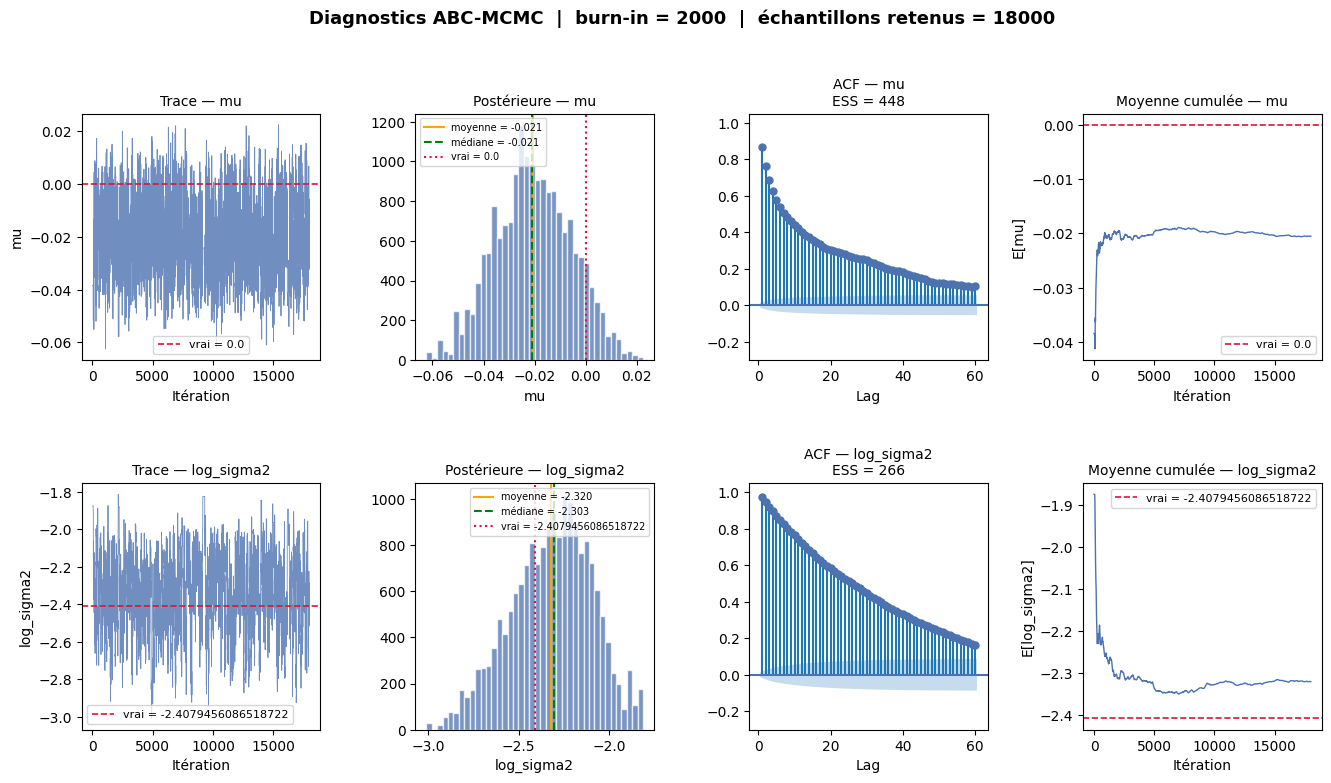

Figure sauvegardée.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


def effective_sample_size(chain_1d):
    """
    ESS = N / (1 + 2 * sum(autocorrelations))
    On tronque la somme quand l'ACF devient négative (méthode de Geyer).
    """
    n = len(chain_1d)
    acf_vals = acf(chain_1d, nlags=min(500, n // 2), fft=True)
    # Méthode de Geyer : on arrête à la première ACF négative
    cutoff = next((i for i, v in enumerate(acf_vals) if v < 0), len(acf_vals))
    ess = n / (1 + 2 * np.sum(acf_vals[1:cutoff]))
    return max(1.0, ess)


def plot_diagnostics(chain, param_names=None, burnin=0, true_values=None):
    """
    Diagnostics complets pour une chaîne ABC-MCMC.

    Paramètres
    ----------
    chain        : np.ndarray (num_samples, n_params)
    param_names  : liste de noms (ex. ['mu', 'log_sigma2'])
    burnin       : nombre d'itérations à ignorer
    true_values  : valeurs vraies (optionnel, pour référence visuelle)
    """
    if param_names is None:
        param_names = [f"theta_{i}" for i in range(chain.shape[1])]

    chain_post = chain[burnin:]
    n_params = chain.shape[1]

    fig = plt.figure(figsize=(16, 4 * n_params))
    gs = gridspec.GridSpec(n_params, 4, figure=fig, hspace=0.5, wspace=0.4)

    for p in range(n_params):
        x = chain_post[:, p]
        name = param_names[p]
        tv = true_values[p] if true_values is not None else None
        ess = effective_sample_size(x)

        # ── 1. Trace plot ──────────────────────────────────────────────────
        ax_trace = fig.add_subplot(gs[p, 0])
        ax_trace.plot(x, lw=0.6, alpha=0.8, color="#4C72B0")
        if tv is not None:
            ax_trace.axhline(tv, color="crimson", lw=1.2, ls="--", label=f"vrai = {tv}")
            ax_trace.legend(fontsize=8)
        ax_trace.set_title(f"Trace — {name}", fontsize=10)
        ax_trace.set_xlabel("Itération")
        ax_trace.set_ylabel(name)

        # ── 2. Histogramme de la postérieure ──────────────────────────────
        ax_hist = fig.add_subplot(gs[p, 1])
        ax_hist.hist(x, bins=40, color="#4C72B0", alpha=0.75, edgecolor="white", lw=0.3)
        ax_hist.axvline(np.mean(x), color="orange", lw=1.5, ls="-",  label=f"moyenne = {np.mean(x):.3f}")
        ax_hist.axvline(np.median(x), color="green",  lw=1.5, ls="--", label=f"médiane = {np.median(x):.3f}")
        if tv is not None:
            ax_hist.axvline(tv, color="crimson", lw=1.5, ls=":", label=f"vrai = {tv}")
        ax_hist.set_title(f"Postérieure — {name}", fontsize=10)
        ax_hist.set_xlabel(name)
        ax_hist.legend(fontsize=7)

        # ── 3. Autocorrélation ────────────────────────────────────────────
        ax_acf = fig.add_subplot(gs[p, 2])
        plot_acf(x, ax=ax_acf, lags=60, alpha=0.05, color="#4C72B0", zero=False)
        ax_acf.set_title(f"ACF — {name}\nESS = {ess:.0f}", fontsize=10)
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylim(-0.3, 1.05)

        # ── 4. Running mean (convergence) ─────────────────────────────────
        ax_run = fig.add_subplot(gs[p, 3])
        running_mean = np.cumsum(x) / np.arange(1, len(x) + 1)
        ax_run.plot(running_mean, lw=1, color="#4C72B0")
        if tv is not None:
            ax_run.axhline(tv, color="crimson", lw=1.2, ls="--", label=f"vrai = {tv}")
            ax_run.legend(fontsize=8)
        ax_run.set_title(f"Moyenne cumulée — {name}", fontsize=10)
        ax_run.set_xlabel("Itération")
        ax_run.set_ylabel(f"E[{name}]")

    fig.suptitle(
        f"Diagnostics ABC-MCMC  |  burn-in = {burnin}  |  échantillons retenus = {len(chain_post)}",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.savefig("diagnostics_abcmcmc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée.")


# ── Rapport console ────────────────────────────────────────────────────────────

def print_summary(chain, param_names=None, burnin=0, true_values=None):
    """Affiche ESS, moyenne, écart-type, IC 95% pour chaque paramètre."""
    if param_names is None:
        param_names = [f"theta_{i}" for i in range(chain.shape[1])]
    chain_post = chain[burnin:]

    print(f"\n{'─'*60}")
    print(f"{'Paramètre':<15} {'Moyenne':>8} {'Std':>8} {'IC 95% bas':>11} {'IC 95% haut':>12} {'ESS':>6}")
    print(f"{'─'*60}")
    for p, name in enumerate(param_names):
        x = chain_post[:, p]
        ess = effective_sample_size(x)
        lo, hi = np.percentile(x, [2.5, 97.5])
        tv_str = f"  (vrai = {true_values[p]:.3f})" if true_values is not None else ""
        print(f"{name:<15} {np.mean(x):>8.4f} {np.std(x):>8.4f} {lo:>11.4f} {hi:>12.4f} {ess:>6.0f}{tv_str}")
    print(f"{'─'*60}\n")


# ── Exemple d'utilisation ──────────────────────────────────────────────────────
from ABCMCMC import ABCMCMC
chain, acc_rate = ABCMCMC(
        Y_obs, L_true, 1, 1, epsilon_val,step_mu,step_log_sigma, num_samples=20000, rng=main_rng
        )

print(f"Taux d'acceptation : {acc_rate:.2%}")
print_summary(chain, param_names=["mu", "log_sigma2"], burnin=2000,
              true_values=[0.0, np.log(0.3**2)])
plot_diagnostics(chain, param_names=["mu", "log_sigma2"], burnin=2000,
true_values=[0.0, np.log(0.3**2)])